Mengubah tingkat kecerahan citra
--------------------------------


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\703934799.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness,0,255)


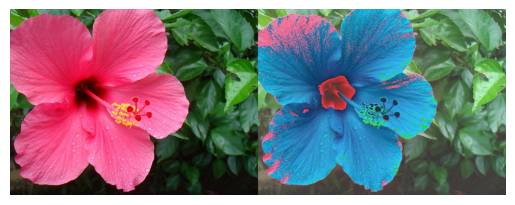

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Eror, not a number')

original = cv.imread('./image/bunga.jpg')
brightness_image = np.zeros(original.shape,original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness,0,255)
final_frame = cv.hconcat((original, brightness_image))
img_rgb = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

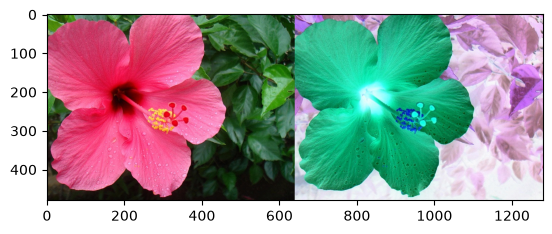

In [ ]:
new = cv.imread('./image/bunga.jpg')
test_img = 255 - new
final_frame_inv = cv.hconcat((new,test_img))

final_frame_rgb = cv.cvtColor(final_frame_inv, cv.COLOR_BGR2RGB)
plt.imshow(final_frame_rgb)

Mengubah kontras dan tingkat kecerahan citra
--------------------------------


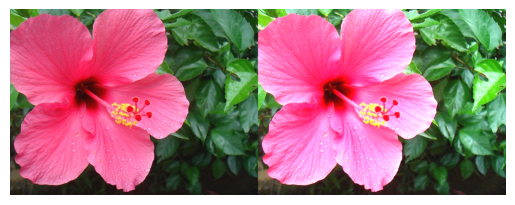

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
    contras = float(input('Masukkan Kontras: '))
except ValueError:
    print('Eror, not a number')

bunga = cv.imread('./image/bunga.jpg')
brightness_image = np.zeros(bunga.shape,bunga.dtype)
contras_image = np.zeros(bunga.shape,bunga.dtype)

for y in range(bunga.shape[0]):
    for x in range(bunga.shape[1]):
        for c in range(bunga.shape[2]):
            brightness_image[y,x,c] = np.clip(int(bunga[y,x,c]) + brightness,0,255)



for y in range(bunga.shape[0]):
    for x in range(bunga.shape[1]):
        for c in range(bunga.shape[2]):
            contras_image[y,x,c] = np.clip(contras * int(bunga[y,x,c]) + brightness,0,255)
final_frame = cv.hconcat((brightness_image, contras_image))
img_rgb = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------


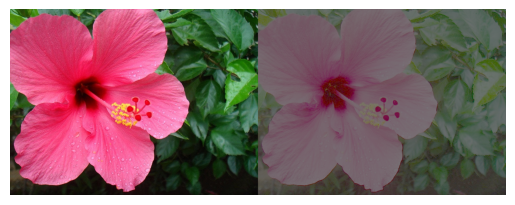

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')
try:
    cerah = int(input("Masukkan nilai kecerahan: "))
except ValueError:
    print('Eror')
flower = cv.imread('./image/bunga.jpg')
log_image = np.zeros(flower.shape,flower.dtype)
for y in range(flower.shape[0]):
    for x in range(flower.shape[1]):
        for c in range(flower.shape[2]):
            log_image[y,x,c] = np.clip(cerah * np.log10(1+int(flower[y,x,c])))
final_frame = cv.hconcat((flower, log_image))
img_rgb = cv.cvtColor(final_frame, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()



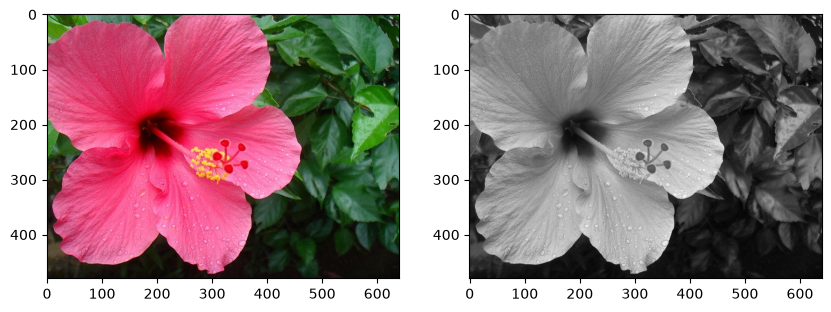

In [ ]:
new = cv.imread('./image/bunga.jpg')
avg_image = np.zeros((new.shape[0],new.shape[1]), dtype=np.uint8)
for y in range(new.shape[0]):
    for x in range(new.shape[1]):
        b = int(new[y,x,0])
        g = int(new[y,x,1])
        r = int(new[y,x,2])
        avg_value = (r + g + b)//3
        avg_image[y,x] = avg_value

img_rgb=cv.cvtColor(new,cv.COLOR_BGR2RGB)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)

plt.subplot(1,2,2)
plt.imshow(avg_image,cmap='gray')
plt.show()

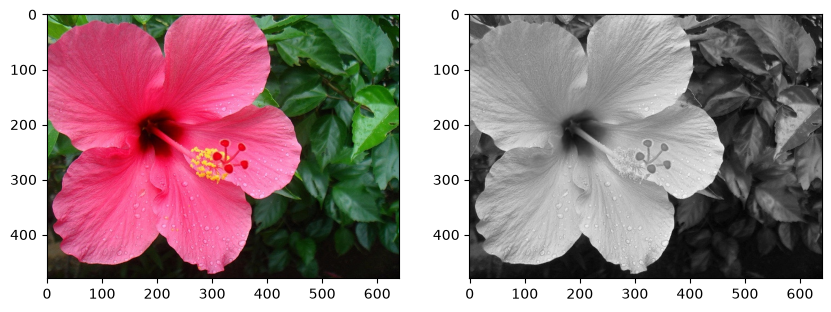

In [21]:
new = cv.imread('./image/bunga.jpg')
avg_image = np.zeros((new.shape[0],new.shape[1]), dtype=np.uint8)
for y in range(new.shape[0]):
    for x in range(new.shape[1]):
        b = int(new[y,x,0])
        g = int(new[y,x,1])
        r = int(new[y,x,2])
        avg_value = (max(r , g , b)+ min(r , g , b))//2
        avg_image[y,x] = avg_value

img_rgb=cv.cvtColor(new,cv.COLOR_BGR2RGB)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)

plt.subplot(1,2,2)
plt.imshow(avg_image,cmap='gray')
plt.show()

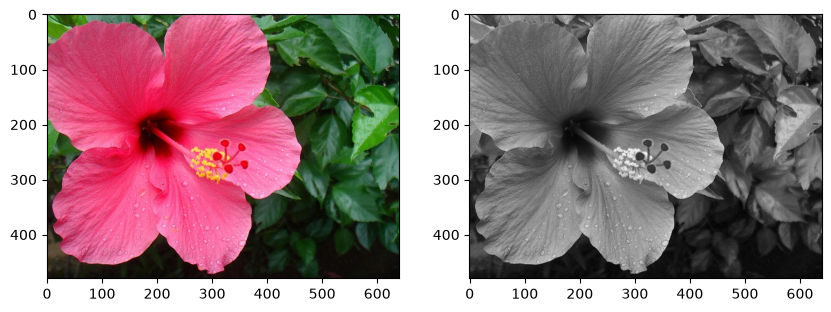

In [ ]:
new = cv.imread('./image/bunga.jpg') #membaca file
avg_image = np.zeros((new.shape[0],new.shape[1]), dtype=np.uint8) #membuat kanvas kosong dengan 2dimensi dengan ukuran tinggi 0 dan lebar 1 dengan tipe data uint8
for y in range(new.shape[0]): 
    for x in range(new.shape[1]):
        b = int(new[y,x,0]) 
        g = int(new[y,x,1])
        r = int(new[y,x,2])
        avg_value = int(0.21*r + 0.72*g + 0.07*b)
        avg_image[y,x] = avg_value #menanamkan nilai abu-abu hasil perhitungan ke korrdinat yang persis di atas kanvas kosong

img_rgb=cv.cvtColor(new,cv.COLOR_BGR2RGB) #menukar susunan warna dari BGR 
plt.figure(figsize=(10,5)) #membuat frame kosong berukuran 10x5 inci
plt.subplot(1,2,1) # membagi bingkai menjadi kisi lalu meletakkan kanvas aktifinya di slot ke 1 (kiri)
plt.imshow(img_rgb)

plt.subplot(1,2,2) #memindahkan kanvas aktif ke slot-2 
plt.imshow(avg_image,cmap='gray')
plt.show()

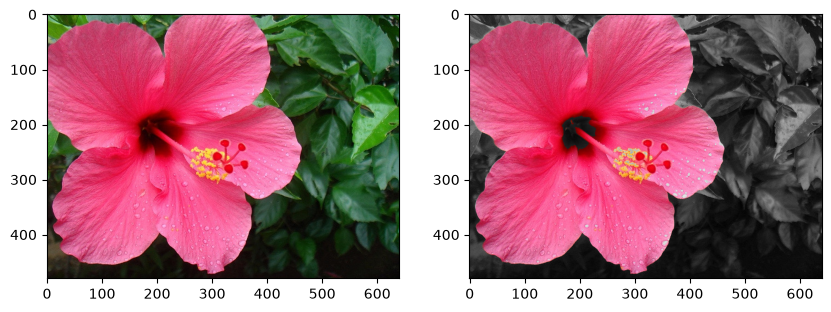

In [5]:
new = cv.imread('./image/bunga.jpg')
can_image = np.zeros(new.shape,new.dtype)

b,g,r = cv.split(new.astype(int))
gray = (r + g + b)//3
gray_total = cv.merge([gray,gray,gray])
mask_merah = (r>100) & (r > g + 40) & (r > b + 40)
mask_3d = cv.merge([mask_merah, mask_merah , mask_merah])
avg_image = np.where(mask_3d,new,gray_total).astype(np.uint8)
img_rgb=cv.cvtColor(new,cv.COLOR_BGR2RGB)
plt.figure(figsize=(10,5)) #membuat frame kosong berukuran 10x5 inci
plt.subplot(1,2,1) # membagi bingkai menjadi kisi lalu meletakkan kanvas aktifinya di slot ke 1 (kiri)
plt.imshow(img_rgb)

avg_img_rgb=cv.cvtColor(avg_image,cv.COLOR_BGR2RGB)
plt.subplot(1,2,2) #memindahkan kanvas aktif ke slot-2 
plt.imshow(avg_img_rgb)
plt.show()

 Gamma Correction pada citra 
----------------------------------


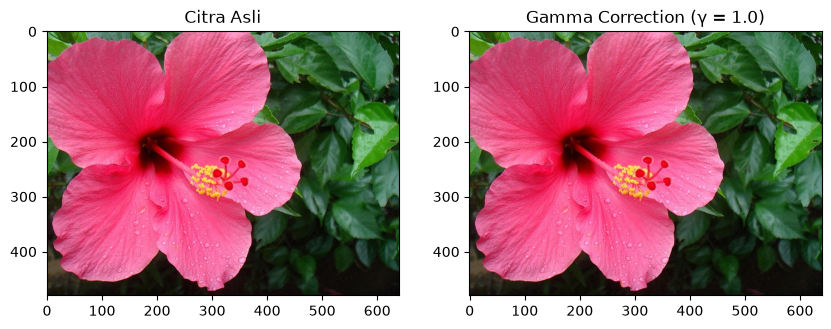

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:

    gamma = float(input('Masukkan nilai Gamma: '))
    

    original = cv.imread('./image/bunga.jpg') 
    
   
    gamma_correction = 255.0 * (original / 255.0) ** (1.0 / gamma)
    
    
    gamma_image = gamma_correction.astype(np.uint8)

  
    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
    gamma_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

  
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title('Citra Asli')
    plt.imshow(original_rgb)
    
    plt.subplot(1, 2, 2)
    plt.title(f'Gamma Correction (\u03b3 = {gamma})')
    plt.imshow(gamma_rgb)
    
    plt.show()

except ValueError:
    print('Error, not a number')

Bit depth awal   : 8 bit
Bit depth tujuan : 8 bit
Jumlah level     : 256


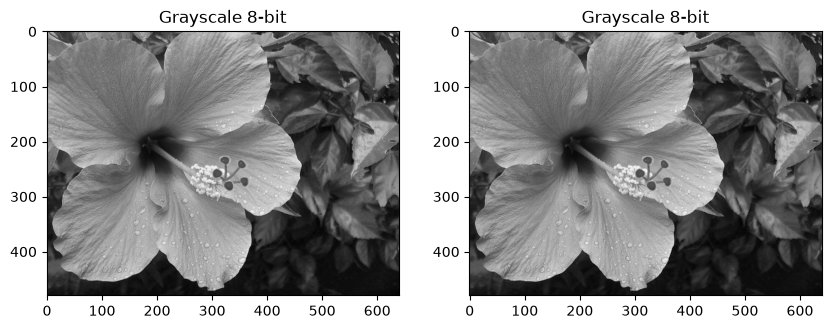

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))
    if not (1 <= bit_depth <= 8):
        print("Mohon masukkan angka antara 1 hingga 8 saja.")
    else:
       
        original = cv.imread('./image/bunga.jpg', cv.IMREAD_GRAYSCALE)
        
     
        jumlah_level = pow(2, bit_depth)
        level = 255.0 / (jumlah_level - 1)
        
        depth_image = np.round(original / level) * level
        
       
        depth_image = depth_image.astype(np.uint8)
        
   
        print(f"Bit depth awal   : 8 bit")
        print(f"Bit depth tujuan : {bit_depth} bit")
        print(f"Jumlah level     : {jumlah_level}")
        
       
        plt.figure(figsize=(10, 5))
        
        plt.subplot(1, 2, 1)
        plt.title('Grayscale 8-bit')
      
        plt.imshow(original, cmap='gray')
        
        plt.subplot(1, 2, 2)
        plt.title(f'Grayscale {bit_depth}-bit')
        plt.imshow(depth_image, cmap='gray')
        
        plt.show()

except ValueError:
    print("Error, pastikan Anda memasukkan angka.")

Tabel Hasil PSNR:
----------------------------------------
Jumlah Citra | Nilai PSNR (dB)
----------------------------------------
     1       | 100.0000
     1       | 100.0000
     1       | 100.0000
     1       | 100.0000
     1       | 100.0000


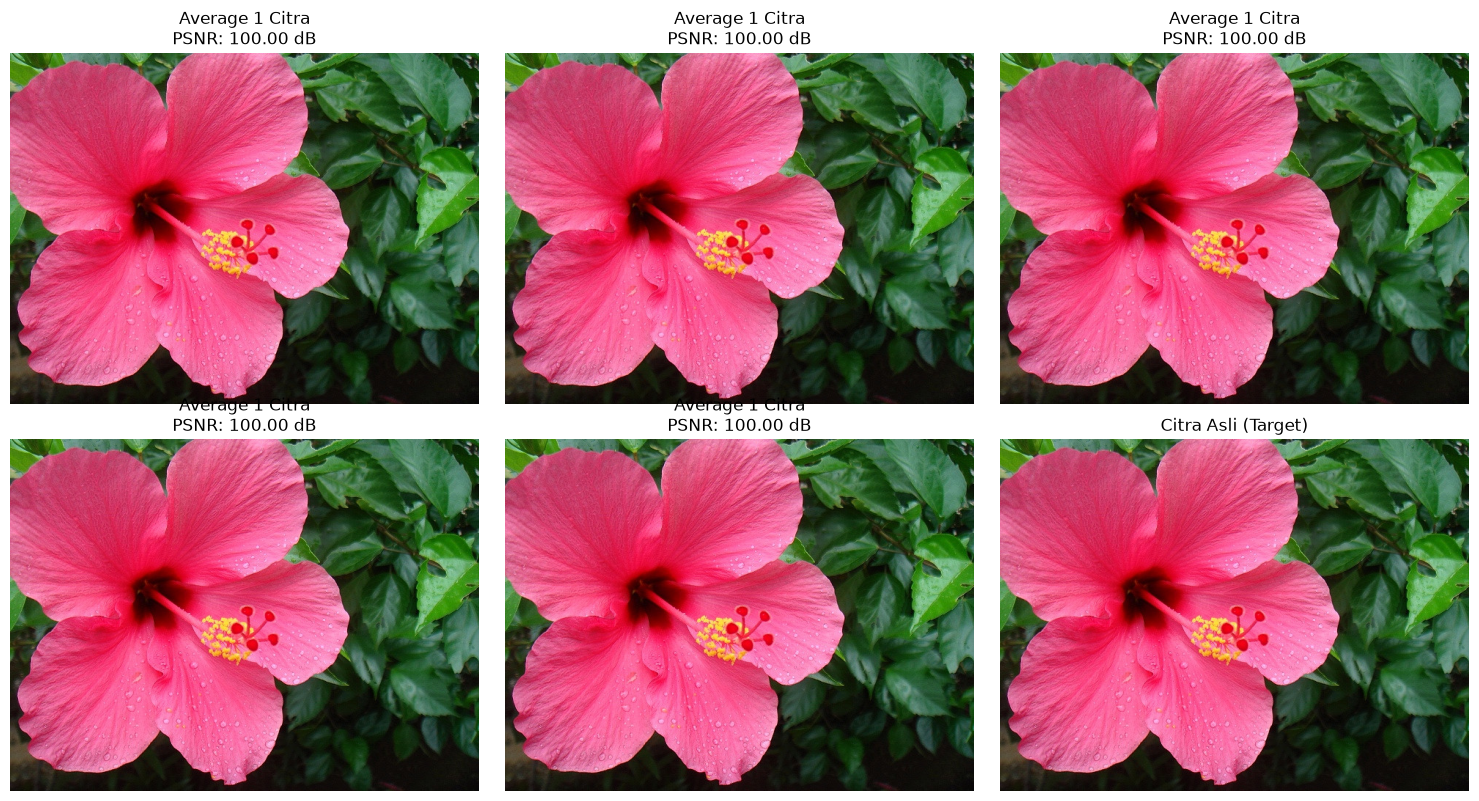

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math

# 1. Definisi Fungsi PSNR (Sesuai modul)
def PSNR(img1, img2):
    # Wajib konversi ke float64 agar perhitungan selisih kuadrat tidak overflow
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

try:
    # 2. Baca Citra Asli
    original_img = cv.imread('./image/bunga.jpg')
    
    # 3. Kumpulkan Citra Noise menggunakan glob
    cv_img = []
    # Sesuaikan path ini dengan folder noises Anda
    for img_path in glob.glob('./image/bunga.jpg'):
        n = cv.imread(img_path)
        if n is not None:
            cv_img.append(n)
            
    if len(cv_img) == 0:
        print("Gambar noise tidak ditemukan. Periksa kembali path folder Anda.")
    else:
        # 4. Skenario jumlah rata-rata citra
        skenario_jumlah = [10, 20, 40, 80, 100]
        
        plt.figure(figsize=(15, 8))
        
        print("Tabel Hasil PSNR:")
        print("-" * 40)
        print("Jumlah Citra | Nilai PSNR (dB)")
        print("-" * 40)
        
        # 5. Looping untuk setiap skenario N
        for i, N in enumerate(skenario_jumlah):
            # Batasi N agar tidak melebihi total gambar yang berhasil dibaca
            N = min(N, len(cv_img))
            
            # Potong list sebanyak N gambar
            sampel = cv_img[:N]
            
            # Hitung rata-rata matriks serentak (Averaging)
            avg_img = np.mean(sampel, axis=0).astype(np.uint8)
            
            # Hitung PSNR hasil Denoising terhadap citra Asli
            nilai_psnr = PSNR(original_img, avg_img)
            
            # Cetak ke layar
            print(f"{N:^12} | {nilai_psnr:.4f}")
            
            # Visualisasi Matplotlib
            avg_img_rgb = cv.cvtColor(avg_img, cv.COLOR_BGR2RGB)
            plt.subplot(2, 3, i+1)
            plt.title(f'Average {N} Citra\nPSNR: {nilai_psnr:.2f} dB')
            plt.imshow(avg_img_rgb)
            plt.axis('off')
            
        # Tampilkan Citra Asli di slot terakhir sebagai pembanding
        plt.subplot(2, 3, 6)
        plt.title('Citra Asli (Target)')
        plt.imshow(cv.cvtColor(original_img, cv.COLOR_BGR2RGB))
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

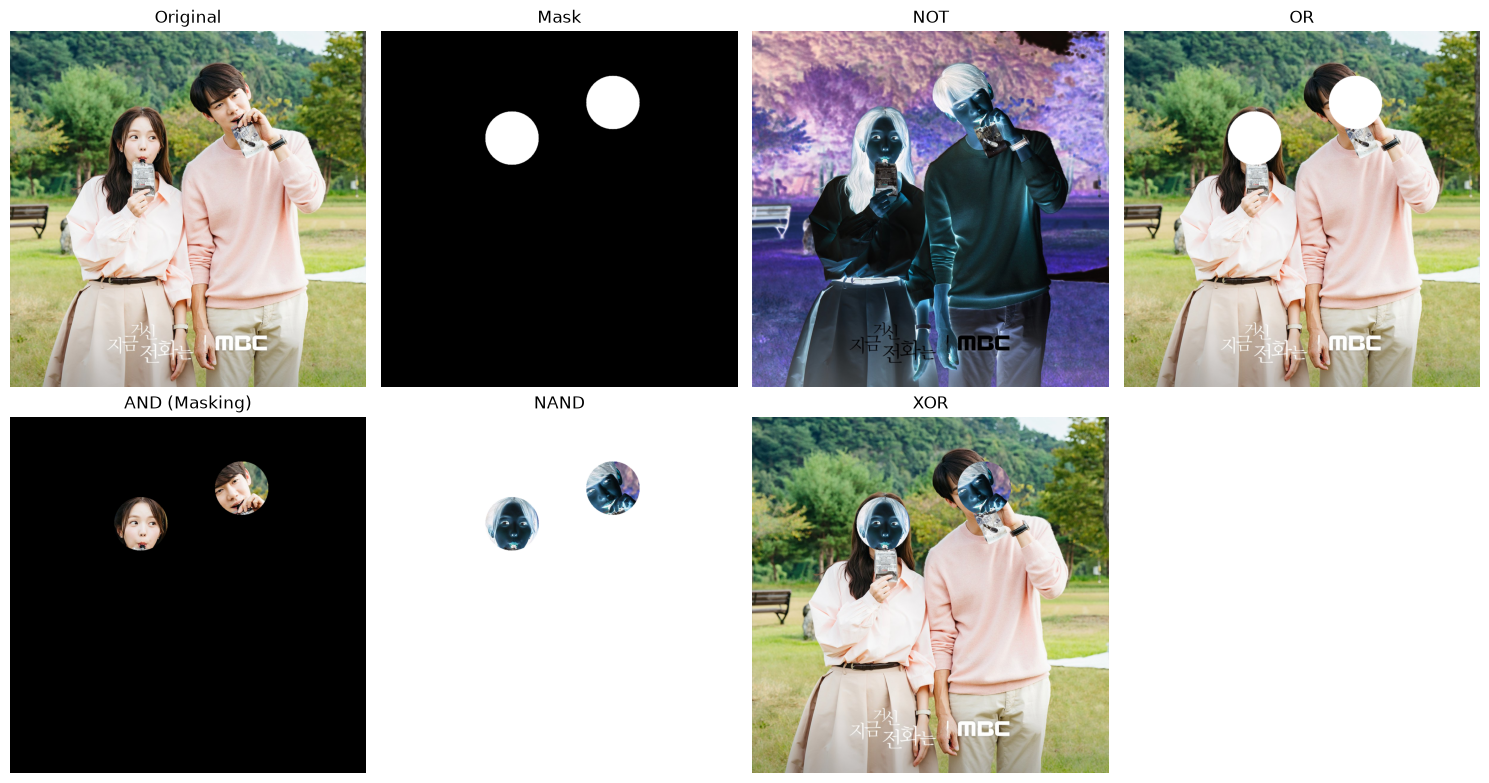

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('./image/couple.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
mask = np.zeros(img.shape[:2], dtype=np.uint8)

cv.circle(mask, (440, 360), 90, 255, -1) 
cv.circle(mask, (780, 240), 90, 255, -1)


mask_3d = cv.merge([mask, mask, mask])

res_not = cv.bitwise_not(img_rgb)


res_or = cv.bitwise_or(img_rgb, mask_3d)
res_and = cv.bitwise_and(img_rgb, mask_3d)


res_nand = cv.bitwise_not(res_and)

res_xor = cv.bitwise_xor(img_rgb, mask_3d)


titles = ['Original', 'Mask', 'NOT', 'OR', 'AND (Masking)', 'NAND', 'XOR']
images = [img_rgb, mask_3d, res_not, res_or, res_and, res_nand, res_xor]

plt.figure(figsize=(15, 8))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.title(titles[i])
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

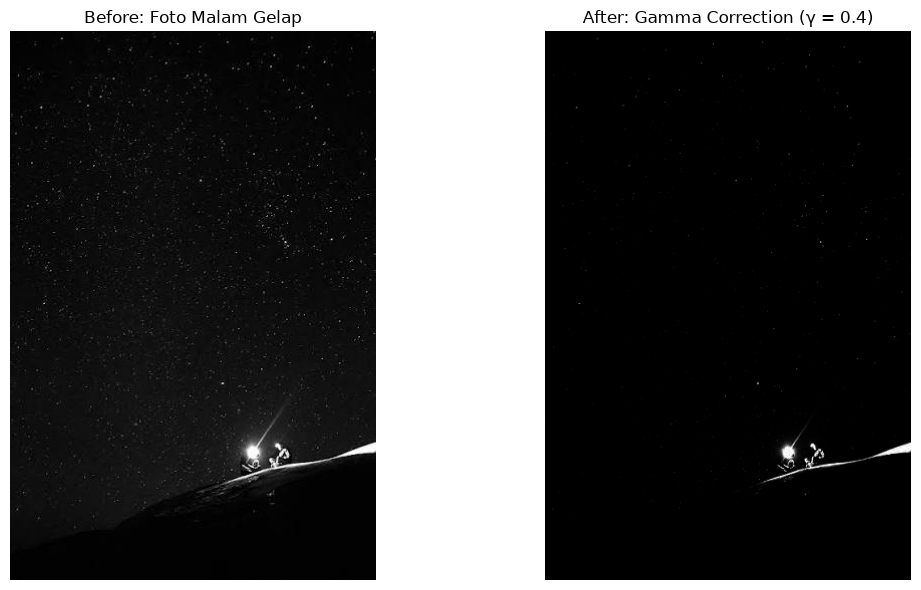

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca foto malam hari (Ganti 'foto_malam.jpg' dengan file Anda)
img_night = cv.imread('./image/gelap.jpg')
img_rgb = cv.cvtColor(img_night, cv.COLOR_BGR2RGB)

# 2. Tentukan nilai Gamma (Gunakan angka di bawah 1.0 untuk mencerahkan)
gamma_value = 0.4

# 3. Eksekusi Gamma Correction (Vectorization)
# Normalisasi -> Pangkatkan dengan (1/gamma) -> Denormalisasi
gamma_correction = 255.0 * (img_rgb / 255.0) ** (1.0 / gamma_value)

# Kembalikan ke format citra standar
img_result = gamma_correction.astype(np.uint8)

# 4. Visualisasi Before - After
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Before: Foto Malam Gelap')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'After: Gamma Correction (\u03b3 = {gamma_value})')
plt.imshow(img_result)
plt.axis('off')

plt.tight_layout()
plt.show()

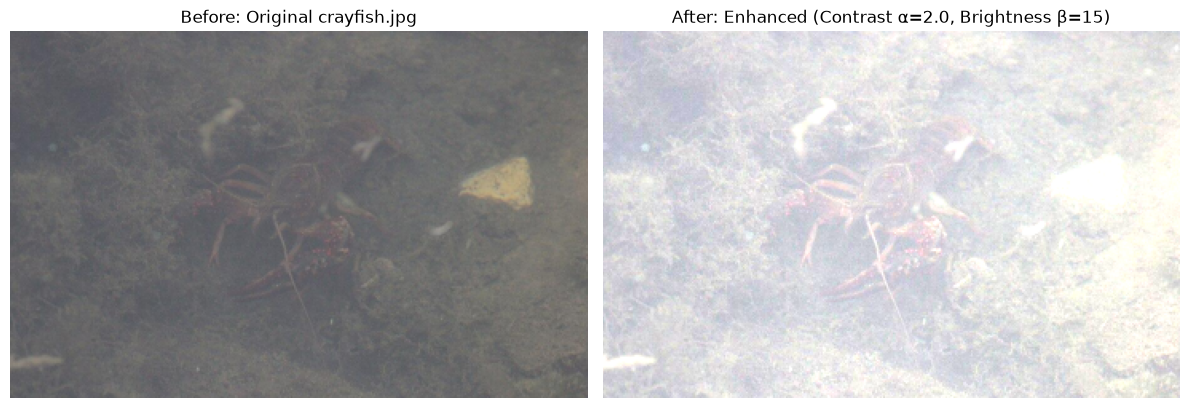

In [12]:
import cv2 as cv
import matplotlib.pyplot as plt


img_cryfish = cv.imread('./image/cryfish.png')
img_rgb = cv.cvtColor(img_cryfish, cv.COLOR_BGR2RGB)


alpha_best = 2.0 
beta_best = 15   


img_enhanced = cv.convertScaleAbs(img_rgb, alpha=alpha_best, beta=beta_best)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Before: Original crayfish.jpg')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'After: Enhanced (Contrast \u03b1={alpha_best}, Brightness \u03b2={beta_best})')
plt.imshow(img_enhanced)
plt.axis('off')

plt.tight_layout()
plt.show()